#**Introduction to scientific Python for comp. physics and atomic simulations**

Download the notebook

## What this notebook covers

The notebook introduces how to:

1. work with Python variables, lists, loops, functions, and a simple class;
2. use **NumPy arrays and vectorization** instead of slow element-by-element Python loops;
3. solve a symmetric **eigenvalue problem** and interpret eigenvalues/eigenvectors as physical modes;
4. use **Matplotlib** to make clear scientific figures;
5. understand what an **overlap matrix** is and why its eigenvalues can be used as invariant structural descriptors;
6. create and manipulate `ase.Atoms`, attach an ASE **calculator**, optimize a structure, run MD, save/read trajectories, and analyze energies;
7. see why ASE is a useful interface between classical models, electronic-structure codes, and modern **machine-learning force fields (MLFFs)**.

### Roadmap

**Python → NumPy → eigenproblems → plotting → overlap descriptors → ASE → optimization → MD → exercises**

### Environment

This notebook uses only standard scientific-Python packages plus **ASE**. Keep `overlap_matrix.py` in the same directory as this notebook before starting the final exercise.


In [80]:
%pip install ase

import numpy as np
import matplotlib.pyplot as plt

# A compact plotting style used throughout the tutorial.
plt.rcParams.update({
    "figure.figsize": (6.0, 4.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})


Mount Google drive in Google Colab virtual machine so you can read and write files directly between notebook to Google drive

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Python basics

Python is popular in computational physics because it is readable, interactive, and has a large scientific ecosystem. Most heavy numerical work is delegated to optimized libraries such as NumPy, SciPy, PyTorch, or compiled simulation codes.


## 1.1 Variables and basic containers

Python chooses the variable type dynamically. A **list** is a flexible Python container; a **NumPy array** (introduced later) is usually better for numerical work.


In [2]:
integer_number = 12
floating_number = 3.5
message = "computational physics"
flag = True

nums = [12, 23, 34, 45, 56]      # list: mutable ordered sequence
point = (1.0, 2.0, 3.0)         # tuple: immutable ordered sequence
ints = {1, 2, 3}             # set: unordered collection of unique elements
parameters = {"mass": 1.0, "k": 4.0}  # dictionary: unordered key -> value mappings

print(type(integer_number), type(floating_number), type(message), type(flag))
print("nums =", nums)
print("first item =", nums[0], "; last item =", nums[-1])
print("unique integers ", ints)
print("spring constant =", parameters["k"])


<class 'int'> <class 'float'> <class 'str'> <class 'bool'>
nums = [12, 23, 34, 45, 56]
first item = 12 ; last item = 56
unique integers  {1, 2, 3}
spring constant = 4.0


## 1.2 Loops, `enumerate`, and conditions

Use a `for` loop when iterating over a known sequence. `enumerate` is usually cleaner than manually indexing `range(len(...))`.


In [3]:
for i, value in enumerate(nums):
    if value % 2 == 0:
        kind = "even"
    else:
        kind = "odd"
    print(i, value, kind)


0 12 even
1 23 odd
2 34 even
3 45 odd
4 56 even


A `while` loop repeats until a condition becomes false. It is useful when the number of iterations is not known beforehand.


In [4]:
i = 0
while i < 3:
    print("i =", i)
    i += 1


i = 0
i = 1
i = 2


## 1.3 Functions

Functions package a calculation into a reusable unit. A short docstring tells future users what the function means.


In [5]:
def kinetic_energy(mass, velocity):
    """Return 1/2 m v^2 for scalar mass and velocity."""
    return 0.5 * mass * velocity**2

print("E_kin =", kinetic_energy(mass=2.0, velocity=3.0))


E_kin = 9.0


A recursive function calls itself. Recursion is elegant for some mathematical definitions, although vectorized/iterative approaches are often faster in numerical physics.


In [ ]:
def factorial(n):
    """Return n! recursively for a non-negative integer n."""
    if n in (0, 1):
        return 1
    return n * factorial(n - 1)

print("5! =", factorial(5))


## 1.4 Classes

A **class** bundles data and functions that belong together. Here the parameters `mass` and `k` are stored in an object, while methods evaluate physical quantities.


In [6]:
class HarmonicOscillator:
    """One-dimensional harmonic oscillator V(x)=1/2 k x^2."""

    def __init__(self, mass=1.0, k=1.0):
        self.mass = mass
        self.k = k

    def potential_energy(self, x):
        return 0.5 * self.k * np.asarray(x)**2

    def angular_frequency(self):
        return np.sqrt(self.k / self.mass)

oscillator = HarmonicOscillator(mass=2.0, k=8.0)
print("omega =", oscillator.angular_frequency())
print("V(0.5) =", oscillator.potential_energy(0.5))


omega = 2.0
V(0.5) = 1.0


# 2. NumPy: arrays, vectorization, and linear algebra

A NumPy `ndarray` stores numbers in a regular block of memory and lets optimized compiled code operate on many entries at once. This is the core idea behind **vectorization**.


In [8]:
nums_array = np.array(nums, dtype=float)
x = np.linspace(0.0, 2.0, 5)

print("Python list type:", type(nums))
print("NumPy array type:", type(nums_array))
print("x =", x)
print("shape =", x.shape, "; dtype =", x.dtype)


Python list type: <class 'list'>
NumPy array type: <class 'numpy.ndarray'>
x = [0.  0.5 1.  1.5 2. ]
shape = (5,) ; dtype = float64


## 2.1 Vectorized arithmetic and broadcasting

Operations act element-by-element without a Python loop. Broadcasting lets arrays of compatible shapes interact.


In [9]:
y = 5.0 * x + 10.0
print("y =", y)

positions = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 2.0, 0.0],
])
origin = np.array([0.5, 0.5, 0.0])

displacements = positions - origin          # broadcasting: (3,3) - (3,)
distances = np.linalg.norm(displacements, axis=1)
print("distances from origin =", distances)


y = [10.  12.5 15.  17.5 20. ]
distances from origin = [0.70710678 0.70710678 1.58113883]


### Loop versus vectorization

Both snippets below compute the same squared distances. The vectorized expression is shorter and, for large arrays, usually much faster because the loop is executed inside optimized numerical code.


In [17]:
from time import time

large_positions = rng.normal(size=(100000, 3))

t0 = time()
# Python-loop version
r2_loop = np.empty(len(large_positions))
for i, r in enumerate(large_positions):
    r2_loop[i] = r[0]**2 + r[1]**2 + r[2]**2
t1 = time()
print(t1 - t0)

# Vectorized version
r2_vectorized = np.sum(large_positions**2, axis=1)
t2 = time()
print(t2 - t1)

print(r2_loop)
print(r2_vectorized)
print("same answer?", np.allclose(r2_loop, r2_vectorized))


0.35828614234924316
0.0049402713775634766
[4.75625421 4.36910181 0.20553738 ... 0.08062136 3.21841684 2.53588595]
[4.75625421 4.36910181 0.20553738 ... 0.08062136 3.21841684 2.53588595]
same answer? True


## 2.2 Matrix multiplication

Use `@` (or `np.matmul`, `np.dot`) for matrix multiplication. `*` means element-wise multiplication.


In [18]:
A = np.array([[2.0, 1.0],
        [1.0, 3.0]])
v = np.array([1.0, -1.0])

print("A @ v =", A @ v)
print("v dot v =", v @ v)
print("element-wise A*A =\n", A * A)


A @ v = [ 1. -2.]
v dot v = 2.0
element-wise A*A =
 [[4. 1.]
 [1. 9.]]


## 2.3 Eigenvalues and eigenvectors: physical modes

For a square matrix $A$, an eigenvector $\mathbf v_i$ satisfies

$
A\mathbf v_i = \lambda_i\mathbf v_i.
$

In computational physics, eigenproblems appear very commonly, such as in geometry optimization, normal-mode analysis, quantum mechanics, covariance/PCA, and descriptor-sensitivity analysis, etc.

For a **real symmetric** matrix, use `np.linalg.eigh` rather than the general `np.linalg.eig`. It returns real eigenvalues and orthonormal eigenvectors faster.


In [19]:
# A simple symmetric stiffness matrix for three coupled coordinates.
K = np.array([
    [ 2.0, -1.0,  0.0],
    [-1.0,  2.0, -1.0],
    [ 0.0, -1.0,  2.0],
])

eigenvalues, eigenvectors = np.linalg.eigh(K)

print("eigenvalues =", eigenvalues)
print("eigenvectors (stored by columns) =\n", eigenvectors)

# Check A v = lambda v for mode 0.
v0 = eigenvectors[:, 0]
residual = K @ v0 - eigenvalues[0] * v0
print("mode-0 residual norm =", np.linalg.norm(residual))


eigenvalues = [0.58578644 2.         3.41421356]
eigenvectors (stored by columns) =
 [[-5.00000000e-01 -7.07106781e-01  5.00000000e-01]
 [-7.07106781e-01  3.12250226e-16 -7.07106781e-01]
 [-5.00000000e-01  7.07106781e-01  5.00000000e-01]]
mode-0 residual norm = 6.004449063730082e-16


> **Important `eigh` detail.** `np.linalg.eigh(A, UPLO="L")` trusts the **lower** triangle of `A`; `UPLO="U"` trusts the **upper** triangle.


In [22]:
print("K symmetric?", np.allclose(K, K.T))
print("V^T V =\n", eigenvectors.T @ eigenvectors)  # should be the identity since the eigenvectors of a symmetric matrix forms an orthogonal set


K symmetric? True
V^T V =
 [[ 1.00000000e+00  2.28779237e-16 -3.33066907e-16]
 [ 2.28779237e-16  1.00000000e+00 -1.76057662e-16]
 [-3.33066907e-16 -1.76057662e-16  1.00000000e+00]]


## 2.4 Reproducible random numbers

Random numbers are used in Monte Carlo, stochastic optimization, and velocity initialization for MD. A fixed seed makes a tutorial reproducible.


In [23]:
rng = np.random.default_rng(seed=42)
print("uniform samples:", rng.random(4))
print("normal samples :", rng.normal(loc=0.0, scale=1.0, size=4))


uniform samples: [0.77395605 0.43887844 0.85859792 0.69736803]
normal samples : [-1.95103519 -1.30217951  0.1278404  -0.31624259]


# 3. Matplotlib for scientific plotting

The most common pattern is: create a figure/axes → plot data → label axes → add a legend → call `plt.show()` (or save the figure).


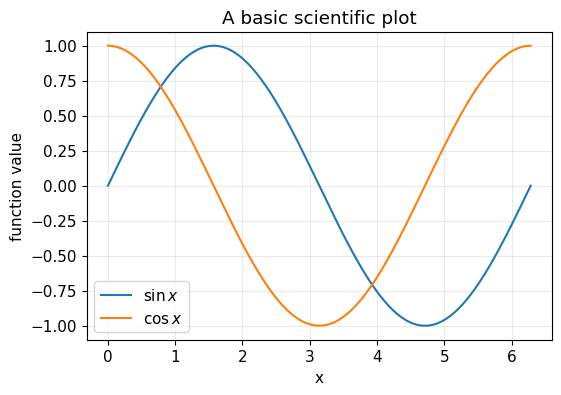

In [24]:
x = np.linspace(0.0, 2.0 * np.pi, 200)

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), label=r"$\sin x$")
ax.plot(x, np.cos(x), label=r"$\cos x$")
ax.set_xlabel("x")
ax.set_ylabel("function value")
ax.set_title("A basic scientific plot")
ax.legend()
plt.show()


# 4. Structural descriptors and the overlap matrix

Machine-learning models cannot usually consume raw Cartesian coordinates without care: the same structure can be translated, rotated, or have atom indices permuted. A **structural descriptor** transforms coordinates into numbers that encode geometry while respecting desired physical symmetries.

## 4.1 What is an overlap matrix?

Imagine placing simple basis functions $\phi_\mu(\mathbf r)$ on atoms. The overlap matrix is

$
O_{\mu\nu}=\int \phi_\mu(\mathbf r)\,\phi_\nu(\mathbf r)\,d\mathbf r.
$

- diagonal terms measure self-overlap;
- off-diagonal terms measure how much two functions spatially overlap;
- the matrix is symmetric and positive semidefinite.

In electronic-structure theory an overlap matrix describes non-orthogonal basis functions. In an **overlap-matrix structural fingerprint**, the basis functions are instead used as a convenient geometric probe: place fixed Gaussian-like orbitals on atoms, construct the overlap matrix, and use its sorted eigenvalues as a fingerprint of the local or global geometry.


### Intuition: two Gaussian functions

For two identical normalized `s`-type Gaussian functions, overlap decays smoothly with separation. The precise width convention can vary; the important idea is that nearby atomic environments produce stronger overlap.


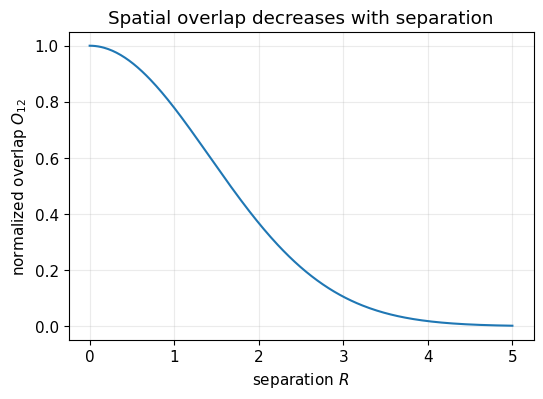

In [27]:
def normalized_s_overlap(distance, width=1.0):
    """Equal-width Gaussian overlap for alpha = 1/(2*width^2)."""
    return np.exp(-(np.asarray(distance)**2) / (4.0 * width**2))

r = np.linspace(0.0, 5.0, 300)
fig, ax = plt.subplots()
ax.plot(r, normalized_s_overlap(r, width=1.0))
ax.set_xlabel(r"separation $R$")
ax.set_ylabel(r"normalized overlap $O_{12}$")
ax.set_title("Spatial overlap decreases with separation")
plt.show()


### Intuition: what does an overlap matrix measure?

An overlap matrix describes **how strongly a set of atom-centered functions overlap in space**.

Consider methane, CH$_4$. Around every atom we place a small set of localized functions

$$
\{s,\;p_x,\;p_y,\;p_z\}.
$$

These functions should be thought of as **mathematical probes of the local atomic environment**. In a structural descriptor, they do not need to correspond to occupied atomic orbitals. For example, we can also place $p$-type functions on H even though the isolated H atom has only a $1s$ electron.

For two basis functions $\phi_\mu(\mathbf r)$ and $\phi_\nu(\mathbf r)$, the overlap matrix element is

$$
S_{\mu\nu}
=
\int
\phi_\mu(\mathbf r)
\phi_\nu(\mathbf r)
\,d\mathbf r.
$$

This gives a symmetric matrix,

$$
\mathbf S=
\begin{pmatrix}
S_{11} & S_{12} & \cdots\\
S_{21} & S_{22} & \cdots\\
\vdots & \vdots & \ddots
\end{pmatrix}.
$$

The meaning of its entries is quite intuitive:

* **Diagonal elements:** a function overlaps completely with itself, so after normalization $S_{\mu\mu}=1$.
* **Large positive values:** two functions occupy similar regions of space with similar signs.
* **Values near zero:** the functions have little spatial overlap, or positive and negative contributions cancel.
* **Negative values:** particularly for $p$ functions, overlapping lobes can have opposite signs.

For CH$_4$ there are five atoms. Using four functions per atom gives a $20\times20$ overlap matrix. The colored blocks below therefore have a simple interpretation:

* the diagonal $4\times4$ blocks describe functions belonging to the **same atom**;
* the C--H blocks describe the environment of carbon relative to each hydrogen;
* the H--H blocks contain information about the relative arrangement of the hydrogen atoms.

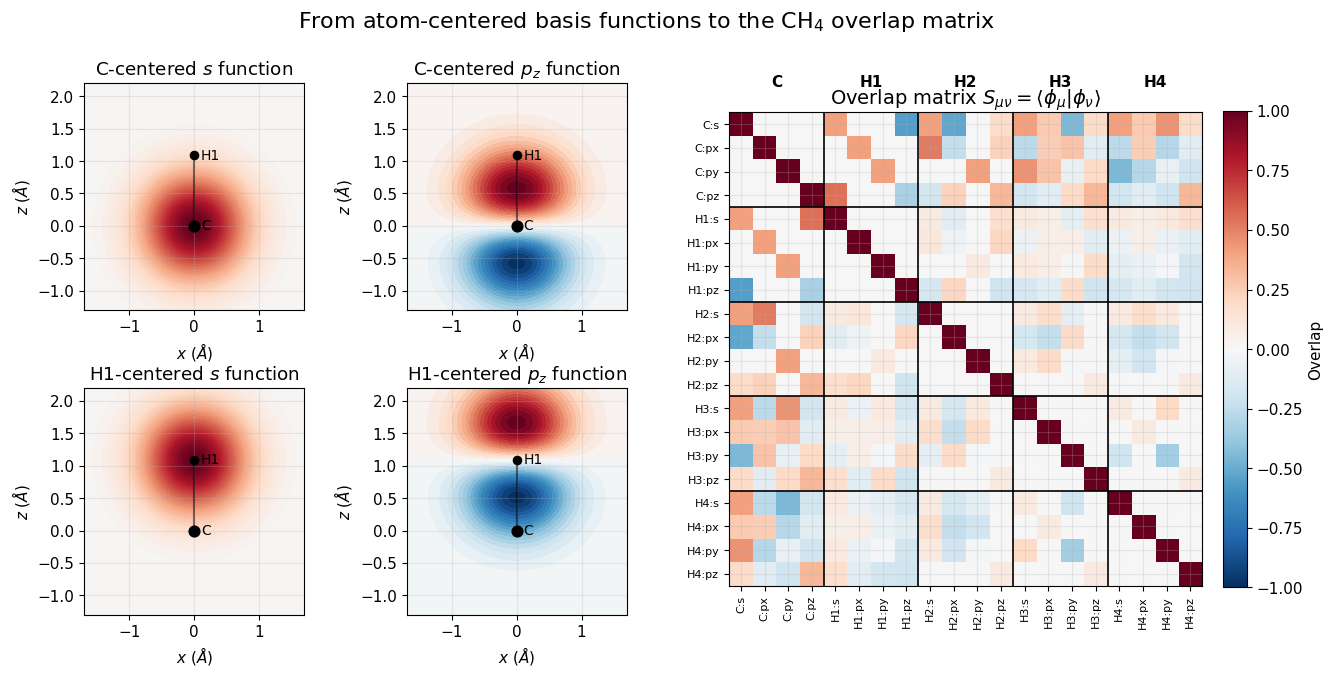

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CH4 geometry
# ============================================================
# Orient CH4 so that the C-H1 bond lies along the z direction.
r_CH = 1.09  # Angstrom

positions = np.array([
    [0.0, 0.0, 0.0],                     # C
    [0.0, 0.0, r_CH],                     # H1
    [2*np.sqrt(2)/3*r_CH, 0.0, -r_CH/3],           # H2
    [-np.sqrt(2)/3*r_CH, np.sqrt(2/3)*r_CH, -r_CH/3],     # H3
    [-np.sqrt(2)/3*r_CH, -np.sqrt(2/3)*r_CH, -r_CH/3],    # H4
])

atom_names = ["C", "H1", "H2", "H3", "H4"]
orbitals = ["s", "px", "py", "pz"]

alpha = 1.5  # controls localization of the Gaussian functions


# ============================================================
# 2. Basis functions
# ============================================================
def basis_values(points, center):
    """
    Return s, px, py, pz Gaussian-type basis functions
    centered at 'center'.
    """
    d = points - center
    r2 = np.sum(d**2, axis=1)

    g = np.exp(-alpha * r2)

    return [
        g,              # s
        d[:, 0] * g,    # px
        d[:, 1] * g,    # py
        d[:, 2] * g,    # pz
    ]


# ============================================================
# 3. Compute the full overlap matrix numerically
# ============================================================
x = np.linspace(-3.0, 3.0, 35)
dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, x, x, indexing="ij")
grid = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

basis_functions = []
labels = []

for atom_name, R in zip(atom_names, positions):

    functions = basis_values(grid, R)

    for orbital, phi in zip(orbitals, functions):

        # Normalize so that <phi|phi> = 1
        norm = np.sqrt(np.sum(phi**2) * dx**3)
        phi = phi / norm

        basis_functions.append(phi)
        labels.append(f"{atom_name}:{orbital}")

basis_functions = np.array(basis_functions)

# S_mu,nu = <phi_mu | phi_nu>
S = basis_functions @ basis_functions.T * dx**3


# ============================================================
# 4. Make 2D slices of selected basis functions
# ============================================================
# Look at the x-z plane (y = 0), which contains the C-H1 bond.
xx = np.linspace(-2.0, 2.0, 200)
zz = np.linspace(-1.5, 2.5, 200)

XX, ZZ = np.meshgrid(xx, zz)
YY = np.zeros_like(XX)

slice_points = np.column_stack([
    XX.ravel(),
    YY.ravel(),
    ZZ.ravel()
])

# C-centered functions
C_functions = basis_values(slice_points, positions[0])

# H1-centered functions
H_functions = basis_values(slice_points, positions[1])

C_s  = C_functions[0].reshape(XX.shape)
C_pz = C_functions[3].reshape(XX.shape)

H_s  = H_functions[0].reshape(XX.shape)
H_pz = H_functions[3].reshape(XX.shape)


# ============================================================
# 5. Plot basis functions + overlap matrix
# ============================================================
fig = plt.figure(figsize=(15, 7))

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 2.35],
    wspace=0.32,
    hspace=0.30
)

# ------------------------------------------------------------
# Helper for plotting one basis function
# ------------------------------------------------------------
def plot_basis(ax, values, title):

    vmax = np.max(np.abs(values))

    im = ax.contourf(
        XX,
        ZZ,
        values,
        levels=40,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )

    # Draw the C-H1 bond
    ax.plot(
        [positions[0, 0], positions[1, 0]],
        [positions[0, 2], positions[1, 2]],
        color="black",
        lw=1.5,
        alpha=0.5,
    )

    # Nuclear positions
    ax.scatter(
        positions[0, 0],
        positions[0, 2],
        s=60,
        color="black",
        zorder=5,
    )

    ax.scatter(
        positions[1, 0],
        positions[1, 2],
        s=35,
        color="black",
        zorder=5,
    )

    ax.text(
        positions[0, 0] + 0.10,
        positions[0, 2],
        "C",
        fontsize=10,
        va="center",
    )

    ax.text(
        positions[1, 0] + 0.10,
        positions[1, 2],
        "H1",
        fontsize=10,
        va="center",
    )

    ax.set_title(title)

    ax.set_xlabel(r"$x$ ($\AA$)")
    ax.set_ylabel(r"$z$ ($\AA$)")

    ax.set_aspect("equal")
    ax.set_xlim(-1.7, 1.7)
    ax.set_ylim(-1.3, 2.2)

    return im


# ------------------------------------------------------------
# C and H basis functions
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
plot_basis(
    ax1,
    C_s,
    r"C-centered $s$ function",
)

ax2 = fig.add_subplot(gs[0, 1])
plot_basis(
    ax2,
    C_pz,
    r"C-centered $p_z$ function",
)

ax3 = fig.add_subplot(gs[1, 0])
plot_basis(
    ax3,
    H_s,
    r"H1-centered $s$ function",
)

ax4 = fig.add_subplot(gs[1, 1])
plot_basis(
    ax4,
    H_pz,
    r"H1-centered $p_z$ function",
)


# ------------------------------------------------------------
# Full overlap matrix
# ------------------------------------------------------------
ax5 = fig.add_subplot(gs[:, 2])

vmax = np.max(np.abs(S))

im = ax5.imshow(
    S,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)

ax5.set_title(
    r"Overlap matrix "
    r"$S_{\mu\nu}=\langle\phi_\mu|\phi_\nu\rangle$",
    fontsize=14,
)

ax5.set_xticks(np.arange(len(labels)))
ax5.set_yticks(np.arange(len(labels)))

ax5.set_xticklabels(
    labels,
    rotation=90,
    fontsize=8,
)

ax5.set_yticklabels(
    labels,
    fontsize=8,
)


# ------------------------------------------------------------
# Separate the atoms into 4x4 blocks
# ------------------------------------------------------------
for boundary in [3.5, 7.5, 11.5, 15.5]:

    ax5.axhline(
        boundary,
        color="black",
        lw=1.2,
    )

    ax5.axvline(
        boundary,
        color="black",
        lw=1.2,
    )


# Atom names above the blocks
for i, name in enumerate(atom_names):

    center = 4 * i + 1.5

    ax5.text(
        center,
        -1.8,
        name,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
    )


# Color bar for the overlap matrix
cbar = fig.colorbar(
    im,
    ax=ax5,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label("Overlap")


fig.suptitle(
    r"From atom-centered basis functions to the CH$_4$ overlap matrix",
    fontsize=16,
    y=0.98,
)

plt.show()

## 4.2 Why take overlap-matrix eigenvalues?
Importantly, the raw matrix depends on how the molecule is oriented because the $p_x$, $p_y$, and $p_z$ functions rotate with the coordinate system. A convenient way to remove this coordinate dependence is to diagonalize the matrix,

$$
\mathbf S\mathbf v_i=\lambda_i\mathbf v_i.
$$

The sorted eigenvalues

$$
(\lambda_1,\lambda_2,\ldots)
$$

are unchanged by a rotation of the basis. They can therefore be used as an **invariant fingerprint of an atomic environment**. This is the basic idea behind overlap-matrix fingerprints used as structural descriptors.

For **local descriptors**, build a neighborhood around each atom and compute one overlap fingerprint per central atom. These atomic fingerprints can be used as **node features** in a molecular/material graph.

This forms a connection to the most active field in modern AI4Science: **machine learning force fields (MLFFs)**. For example, **EOSnet** MLFF uses eigenvalues of atom-centered Gaussian overlap matrices as node features, providing invariant information about many-body local environments before message passing in its graph neural network. One can then train a MLFF model that maps the descriptor of each graph to quantum mechanical properties like potential energy and atomic forces, and then simulate atom movements by predicting atomic forces (e.g. geometry optimization and molecular dynamics).

## 4.3 Comparing local atomic environments

For a **local** OM descriptor, we build one neighborhood around every atom and diagonalize its local overlap matrix. Each atom therefore receives a vector of invariant eigenvalues,

$
\mathbf f_i=(\lambda_{i1},\lambda_{i2},\ldots).
$

Atoms with very similar local geometry and chemistry should have similar **fingerprint vectors**. CH₄ gives a very intuitive example:

- the central C atom has one kind of environment;
- the four H atoms are symmetry-equivalent in ideal CH₄, so their local OM fingerprints should be identical (or numerically very close after a finite-tolerance optimization).

A single eigenvalue such as the largest one, $\lambda_1$, is useful for a simple visualization, although in real applications we often need to compare the **full fingerprint vector**.

In [83]:
!wget https://github.com/ShaunHan/comp_physics_course/blob/main/overlap_matrix.py

--2026-09-11 15:37:47--  https://github.com/ShaunHan/comp_physics_course/blob/main/overlap_matrix.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘overlap_matrix.py.1’

overlap_matrix.py.1     [ <=>                ] 366.98K  --.-KB/s    in 0.02s   

2026-09-11 15:37:47 (19.4 MB/s) - ‘overlap_matrix.py.1’ saved [375785]



### The supplied `overlap_matrix.py`

The helper script follows the main ideas of overlap-matrix fingerprints: Gaussian `s/p` functions, widths related to covalent radii, normalization, and smooth atom-centered cutoffs.

The script deliberately returns the **local overlap matrices**, not their eigenvalues:

```python
local_overlap_matrices(atoms, cutoff=3.0)
```

The invariant fingerprint is obtained by diagonalizing each symmetric overlap matrix. That step is kept in the notebook so the eigenvalues are computed explicitly with NumPy:

```python
np.linalg.eigvalsh(...)
```

In [84]:
# We will use this after introducing ASE.
from overlap_matrix import local_overlap_matrices

# 5. ASE: Atomic Simulation Environment

ASE is a Python framework for setting up, running, and analyzing atomistic simulations. The central design is deliberately modular:

<div style="display:flex; gap:14px; align-items:stretch; margin:16px 0; flex-wrap:wrap;">
  <div style="flex:1; min-width:190px; padding:14px; border:1px solid #ccd; border-radius:12px;"><b>Structure</b><br><code>ase.Atoms</code><br><small>elements, positions, cell, PBC, momenta…</small></div>
  <div style="display:flex; align-items:center; font-size:26px;">→</div>
  <div style="flex:1; min-width:190px; padding:14px; border:1px solid #ccd; border-radius:12px;"><b>Calculator</b><br><small>LJ · EMT · DFT · MLIP</small><br><code>E, F, stress, ...</code></div>
  <div style="display:flex; align-items:center; font-size:26px;">→</div>
  <div style="flex:1; min-width:190px; padding:14px; border:1px solid #ccd; border-radius:12px;"><b>Driver</b><br><small>optimization · MD · NEB · vibrations…</small></div>
</div>

Because optimizers and MD ask the `Atoms` object for forces, changing the underlying physics can be as simple as attaching a different calculator.


## 5.1 Imports and notebook visualization helpers

The helper functions below are longer than the physics examples because Jupyter notebooks need some machinery to render static structures and trajectories. You can treat them as utilities for now.


In [43]:
import os
from IPython.display import HTML
import matplotlib.image as mpimg
from matplotlib.animation import FuncAnimation

from ase import Atoms, units
from ase.build import molecule, bulk
from ase.io import read, write
from ase.visualize import view

os.makedirs("output", exist_ok=True)


def view_x3d(atoms_or_trajectory, idx=0):
    """Interactive X3D view of one ASE Atoms object or one trajectory frame."""
    if isinstance(atoms_or_trajectory, Atoms):
        target = atoms_or_trajectory
    else:
        target = atoms_or_trajectory[idx]
    return view(target, viewer="x3d")


def view_ase_atoms(atoms, rotation="0x,0y,0z", figsize=(4, 4), title="", scale=100):
    """Render an ASE structure through a temporary PNG file."""
    filename = "output/_tmp_atoms.png"
    write(filename, atoms, rotation=rotation, scale=scale)
    image = mpimg.imread(filename)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    os.remove(filename)


def traj_to_apng(trajectory, rotation="30x,30y,30z", stride=1):
    """Return a browser animation for a list/trajectory of ASE Atoms objects."""
    frames = []
    filename = "output/_tmp_frame.png"
    for atoms in trajectory[::stride]:
        write(filename, atoms, rotation=rotation, show_unit_cell=2)
        frames.append(mpimg.imread(filename).copy())
    if os.path.exists(filename):
        os.remove(filename)

    fig, ax = plt.subplots()
    ax.axis("off")

    def update(frame):
        ax.clear()
        ax.axis("off")
        ax.imshow(frame)
        return []

    animation = FuncAnimation(fig, update, frames=frames, blit=False)
    plt.close(fig)
    return HTML(animation.to_jshtml())


## 5.2 The `ase.Atoms` object

`Atoms` stores the structural state: atomic species, Cartesian positions, simulation cell, periodic boundary flags, masses, momenta, constraints, and more. Positions are in Å; energies returned by standard ASE calculators are normally in eV and forces in eV/Å.


Atoms(symbols='CH4', pbc=False, cell=[9.258236, 9.258236, 9.258236])
symbols   : CH4
numbers   : [6 1 1 1 1]
positions :
 [[4.629118 4.629118 4.629118]
 [5.258236 5.258236 5.258236]
 [4.       4.       5.258236]
 [5.258236 4.       4.      ]
 [4.       5.258236 4.      ]]
cell      :
 Cell([9.258236, 9.258236, 9.258236])
pbc       : [False False False]
masses    : [12.011  1.008  1.008  1.008  1.008]


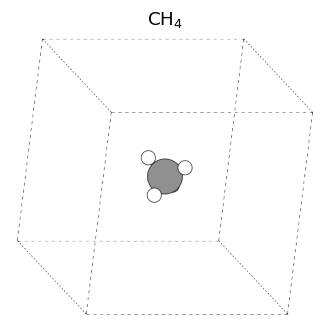

In [44]:
methane = molecule("CH4")
methane.center(vacuum=4.0)

print(methane)
print("symbols   :", methane.symbols)
print("numbers   :", methane.numbers)
print("positions :\n", methane.positions)
print("cell      :\n", methane.cell)
print("pbc       :", methane.pbc)
print("masses    :", methane.get_masses())

view_ase_atoms(methane, rotation="20x,20y,0z", title="CH$_4$")

ASE also has structure builders. For example, `bulk` creates periodic crystals.


Atoms(symbols='Cu4', pbc=True, cell=[3.61, 3.61, 3.61])
cell volume = 47.04588100000001 Å^3


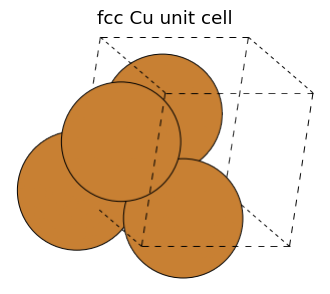

In [45]:
cu_bulk = bulk("Cu", "fcc", a=3.61, cubic=True)
print(cu_bulk)
print("cell volume =", cu_bulk.get_volume(), "Å^3")
view_ase_atoms(cu_bulk, rotation="20x,25y,0z", title="fcc Cu unit cell", scale=45)


## 5.3 Reading and writing structures

ASE supports many file formats. Extended XYZ (`extxyz`) and ASE trajectory (`.traj`) files are convenient because they can also store calculator results.


In [46]:
write("output/methane.extxyz", methane)
methane_from_file = read("output/methane.extxyz")
print(methane_from_file)

Atoms(symbols='CH4', pbc=False, cell=[9.258236, 9.258236, 9.258236])


## 5.4 Calculators: where the physics lives

An `Atoms` object by itself does **not** know its energy. Attach a calculator, then ask for physical properties:

```python
atoms.calc = calculator
energy = atoms.get_potential_energy()
forces = atoms.get_forces()
```

The same interface is used for simple empirical models, quantum mechanical methods, and MLFFs.


### Lennard–Jones potential: a deliberately simple CH₄ toy model

ASE's basic Lennard–Jones (LJ) calculator implements

$
U(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right].
$

A real methane potential must distinguish C–H bonding, H–C–H angles, and chemical species. The single-parameter-pair LJ calculator does **not** do that. It is used here only as a toy potential for demonstrating the ASE workflow.

To keep this toy CH₄ simulation numerically well behaved:

1. the four C–H bond lengths are constrained;
2. `sigma` is chosen so the LJ pair minimum coincides with the C–H bond length, avoiding a large artificial repulsive force at 1.09 Å;
3. `epsilon` is small, and geometry-optimization steps and MD time steps are conservative.

The resulting trajectory is numerically convenient but should not be interpreted as a realistic methane force field.

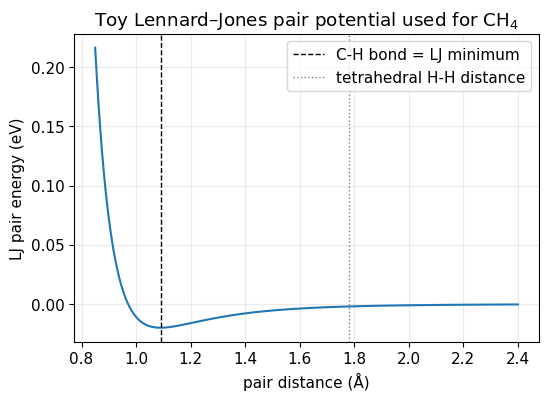

C-H bond length          = 1.090 Å
tetrahedral H-H distance = 1.779 Å


In [47]:
from ase.calculators.lj import LennardJones

# Geometry of ideal tetrahedral methane.
ch_bond = methane.get_distance(0, 1)
hh_target = np.sqrt(8.0 / 3.0) * ch_bond

# LJ minimum: r_min = 2^(1/6) * sigma.
# Place the minimum at the constrained C-H bond length so the bonded pairs
# do not sit on the steep repulsive wall of the pair potential.
sigma_ch4 = ch_bond / 2**(1/6)
epsilon_ch4 = 0.02  # eV

lj_ch4 = LennardJones(
    epsilon=epsilon_ch4,
    sigma=sigma_ch4,
    rc=3.0 * sigma_ch4,
    smooth=True,
)

r = np.linspace(0.85, 2.4, 250)
U = 4 * epsilon_ch4 * ((sigma_ch4 / r)**12 - (sigma_ch4 / r)**6)

fig, ax = plt.subplots()
ax.plot(r, U)
ax.axvline(ch_bond, color="black", ls="--", lw=1, label="C-H bond = LJ minimum")
ax.axvline(hh_target, color="gray", ls=":", lw=1, label="tetrahedral H-H distance")
ax.set_xlabel("pair distance (Å)")
ax.set_ylabel("LJ pair energy (eV)")
ax.set_title("Toy Lennard–Jones pair potential used for CH$_4$")
ax.legend()
plt.show()

print(f"C-H bond length          = {ch_bond:.3f} Å")
print(f"tetrahedral H-H distance = {hh_target:.3f} Å")

<div style="padding:14px 16px; border-left:5px solid #d97706; background:#fff7ed; border-radius:8px;">
<b>Why the constraints?</b><br><br>
The ASE <code>LennardJones</code> calculator uses the same isotropic pair interaction for C–H, H–H, and C–C pairs. If unconstrained, it has no mechanism that knows a C–H bond should remain near 1.09 Å, so methane can collapse or fly apart. Fixing the four C–H distances removes that unphysical bond-stretching degree of freedom. The remaining H–H interactions provide a simple angular restoring tendency around a tetrahedral structure.
<br><br>
This keeps the optimization and MD numerically controlled, but the trajectory should <b>not</b> be interpreted as quantitatively realistic methane dynamics.
</div>

### Build a slightly distorted, but stable, CH₄ starting structure

We perturb the H directions a little while keeping every C–H distance unchanged. The optimizer can then relax the **shape** of the tetrahedron without allowing the molecule to dissociate.

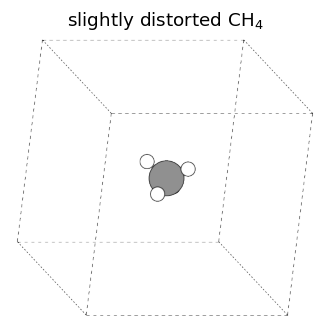

In [49]:
ch4_start = methane.copy()
ch4_start.rattle(stdev=0.05)
view_ase_atoms(ch4_start, rotation="20x,20y,0z", title="slightly distorted CH$_4$")

## 5.5 Geometry optimization

A geometry optimizer follows the forces toward a nearby minimum of the chosen potential-energy surface. Here the C–H bond lengths are fixed, so BFGS mainly relaxes the angular arrangement of the four H atoms.

`maxstep` is kept small because this is intentionally a very simple toy potential.

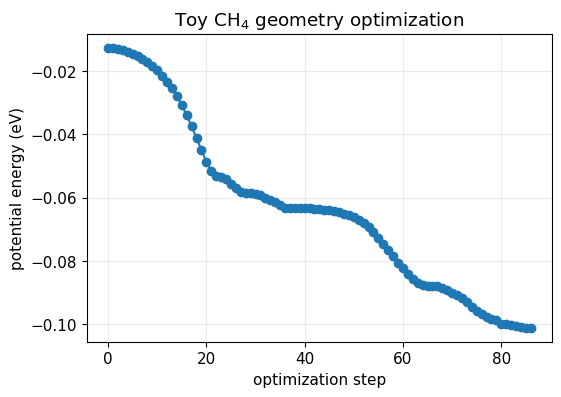

saved optimization frames = 87
final max force = 0.0026679007176347532 eV/Å


In [52]:
from ase.optimize import BFGS
from ase.constraints import FixBondLengths


ch4_opt = ch4_start.copy()
ch4_opt.calc = lj_ch4
ch4_opt.set_constraint(FixBondLengths([(0, i) for i in range(1, 5)]))

optimizer = BFGS(
    ch4_opt,
    trajectory="output/ch4_opt.traj",
    logfile="output/ch4_opt.log",
    maxstep=0.02,
)
optimizer.run(fmax=0.005, steps=100)

ch4_opt_frames = read("output/ch4_opt.traj", index=":")
opt_energies = np.array([frame.get_potential_energy() for frame in ch4_opt_frames])

fig, ax = plt.subplots()
ax.plot(opt_energies, "o-")
ax.set_xlabel("optimization step")
ax.set_ylabel("potential energy (eV)")
ax.set_title("Toy CH$_4$ geometry optimization")
plt.show()

print("saved optimization frames =", len(ch4_opt_frames))
print("final max force =", np.abs(ch4_opt.get_forces()).max(), "eV/Å")

The analysis pattern is intentionally simple: `read(..., index=":")` returns a **list of `Atoms` objects**, and one short list comprehension extracts the stored energy from every frame. Exercise A asks you to repeat exactly this pattern.

## 5.6 Molecular dynamics

MD numerically integrates Newton's equations,

$
m_i\ddot{\mathbf R}_i=\mathbf F_i.
$

Hydrogen is light, so molecular dynamics normally requires a small time step. Here we use a time step of **0.1 fs**.

In [53]:
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

ch4_md = ch4_opt.copy()
ch4_md.calc = lj_ch4
ch4_md.set_constraint(FixBondLengths([(0, i) for i in range(1, 5)]))

T = 10.0  # K
rng_md = np.random.RandomState(7)
MaxwellBoltzmannDistribution(ch4_md, temperature_K=T, rng=rng_md)
Stationary(ch4_md)    # remove net translation
ZeroRotation(ch4_md)  # remove net rigid rotation

md_timestep_fs = 0.1
md_loginterval = 10

md = Langevin(
    ch4_md,
    timestep=md_timestep_fs * units.fs,
    temperature_K=T,
    friction=0.05 / units.fs,
    fixcm=True,
    trajectory="output/ch4_md.traj",
    logfile="output/ch4_md.log",
    loginterval=md_loginterval,
)
md.run(1000)  # 100 fs total

/tmp/ipykernel_3467/178091339.py:10: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(ch4_md, temperature_K=T, rng=rng_md)
/usr/local/lib/python3.13/dist-packages/ase/md/langevin.py:102: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


True

### Analyze the MD trajectory

Trajectory frames retain positions, momenta, and stored calculator results. We can therefore analyze the saved CH₄ dynamics without recomputing the forces.

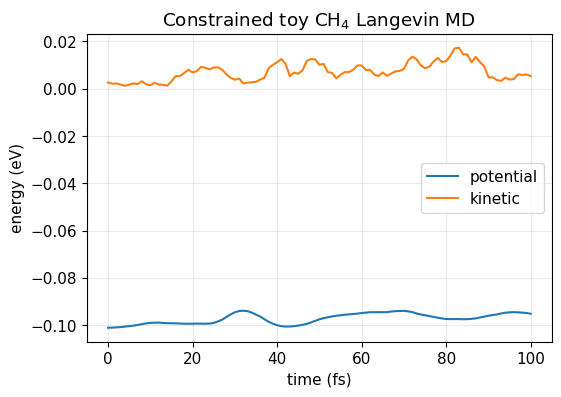

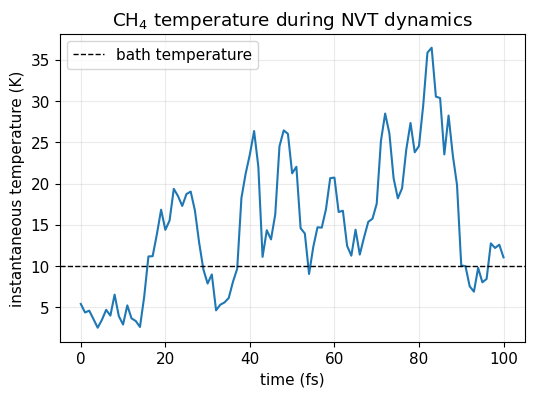

In [79]:
md_frames = read("output/ch4_md.traj", index=":")

potential = np.array([frame.get_potential_energy() for frame in md_frames])
kinetic = np.array([frame.get_kinetic_energy() for frame in md_frames])
temperature = np.array([frame.get_temperature() for frame in md_frames])

time_fs = md_loginterval * md_timestep_fs * np.arange(len(md_frames))

fig, ax = plt.subplots()
ax.plot(time_fs, potential, label="potential")
ax.plot(time_fs, kinetic, label="kinetic")
ax.set_xlabel("time (fs)")
ax.set_ylabel("energy (eV)")
ax.set_title("Constrained toy CH$_4$ Langevin MD")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(time_fs, temperature)
ax.axhline(T, color="black", ls="--", lw=1, label="bath temperature")
ax.set_xlabel("time (fs)")
ax.set_ylabel("instantaneous temperature (K)")
ax.set_title("CH$_4$ temperature during NVT dynamics")
ax.legend()
plt.show()

Because this is **NVT Langevin** dynamics, the molecule exchanges energy with a heat bath, so the instantaneous total energy is not expected to be perfectly constant. The key workflow is: structure → calculator → dynamics → trajectory → analysis.

In [55]:
# Optional trajectory visualization.
traj_to_apng(md_frames, stride=3)

## 5.7 ASE as the bridge to AI-driven atomistic simulation

The workflow above does not care *how* forces are generated. A modern ML interatomic potential can implement the ASE calculator interface and immediately participate in ASE optimization, MD, NEB, phonons, and other workflows.

This separation of **structure**, **physics calculator**, and **simulation driver** is one reason ASE is so useful in current computational physics: the surrounding workflow can stay almost unchanged when moving from a simple pair potential to quantum mechanical methods or to a machine-learned force field.

# 6. Exercises — CH₄ MD trajectory analysis and local OM fingerprints

Both exercises use the same CH₄ example from the notebook and require only short NumPy/Matplotlib code.

In [76]:
# Reuse the geometry-optimization trajectory from Section 5.5.
exercise_frames = read("output/ch4_md.traj", index=":")
exercise_atoms = exercise_frames[-1].copy()

atom_indices = np.arange(len(exercise_atoms))
atom_symbols = exercise_atoms.get_chemical_symbols()

print("number of frames =", len(exercise_frames))
print("atoms =", list(enumerate(atom_symbols)))

number of frames = 101
atoms = [(0, 'C'), (1, 'H'), (2, 'H'), (3, 'H'), (4, 'H')]


## Exercise A — plot the MD total energy

`exercise_frames` is a list of `ase.Atoms` objects.

1. Extract the total energy (= potential energy + kinetic energy) from every frame with a list comprehension.
2. Plot total energy vs. MD step.

In [78]:
# TODO: collect total energies from the exercise_frames and plot the total energy as a function of MD step


## Exercise B — use overlap-matrix eigenvalues to identify similar atomic environments

Consider an ideal CH$_4$ molecule. Atom 0 is C and atoms 1–4 are H.

The four H atoms are related by tetrahedral symmetry, so they have equivalent
local atomic environments. The C atom has a different local environment.

For every atom, `local_overlap_matrices(...)` constructs a symmetric local
overlap matrix. The eigenvalues of this matrix form an invariant fingerprint,

$
\mathbf f_i =
(\lambda_{i1},\lambda_{i2},\lambda_{i3},\ldots).
$

Your task is to:

1. construct the local overlap matrices;
2. calculate their eigenvalues yourself using `np.linalg.eigvalsh`;
3. sort them from largest to smallest;
4. plot the **first four** eigenvalues against atom index.

If the descriptor works as expected, atoms 1–4 should have almost identical
curves because all four H atoms have equivalent environments, whereas atom 0
(C) should be different.

In [68]:
from ase.build import molecule
from overlap_matrix import local_overlap_matrices

# Ideal tetrahedral methane
exercise_atoms = molecule("CH4")
atom_indices = np.arange(len(exercise_atoms))

# TODO:
# 1. Compute the local overlap matrices.
# 2. Compute and sort their eigenvalues with np.linalg.eigvalsh.
# 3. Plot lambda_1, ..., lambda_4 vs. atom index in different lines.

**A faster solution?** Hint: For CH₄ with a 3 Å cutoff, every local matrix contains the same five atoms, so the matrices have the same shape and can be diagonalized together in one NumPy call.